In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib

In [4]:
from google.colab import files
uploaded = files.upload()


Saving dataset_med.csv to dataset_med.csv


In [7]:
lung_dataset = pd.read_csv('dataset_med.csv')

In [9]:
lung_dataset.head()

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


In [10]:
lung_dataset.shape

(890000, 17)

In [11]:
lung_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890000 entries, 0 to 889999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  890000 non-null  int64  
 1   age                 890000 non-null  float64
 2   gender              890000 non-null  object 
 3   country             890000 non-null  object 
 4   diagnosis_date      890000 non-null  object 
 5   cancer_stage        890000 non-null  object 
 6   family_history      890000 non-null  object 
 7   smoking_status      890000 non-null  object 
 8   bmi                 890000 non-null  float64
 9   cholesterol_level   890000 non-null  int64  
 10  hypertension        890000 non-null  int64  
 11  asthma              890000 non-null  int64  
 12  cirrhosis           890000 non-null  int64  
 13  other_cancer        890000 non-null  int64  
 14  treatment_type      890000 non-null  object 
 15  end_treatment_date  890000 non-nul

In [12]:
lung_dataset.duplicated().sum()

np.int64(0)

In [13]:
lung_dataset.drop("id", axis=1, inplace=True)

In [14]:
lung_dataset["diagnosis_date"] = pd.to_datetime(lung_dataset["diagnosis_date"])
lung_dataset["end_treatment_date"] = pd.to_datetime(lung_dataset["end_treatment_date"])

In [16]:
lung_dataset["treatment_duration"] = (
    lung_dataset["end_treatment_date"] - lung_dataset["diagnosis_date"]
).dt.days

In [17]:
lung_dataset.drop(
    ["diagnosis_date", "end_treatment_date"],
    axis=1,
    inplace=True
)

Encoding

In [18]:
label_encoders = {}

categorical_cols = lung_dataset.select_dtypes(include="object").columns

for col in categorical_cols:
    le = LabelEncoder()
    lung_dataset[col] = le.fit_transform(lung_dataset[col])
    label_encoders[col] = le

In [19]:
lung_dataset.head()

,age,gender,country,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,survived,treatment_duration
0,64.0,1,26,0,1,3,29.4,199,0,0,1,0,0,0,523
1,50.0,0,19,2,1,3,41.2,280,1,1,0,0,3,1,424
2,65.0,0,12,2,1,1,44.0,268,1,1,0,0,1,0,370
3,51.0,0,1,0,0,3,43.0,241,1,1,0,0,0,0,443
4,37.0,1,17,0,0,3,19.7,178,0,0,0,0,1,0,406


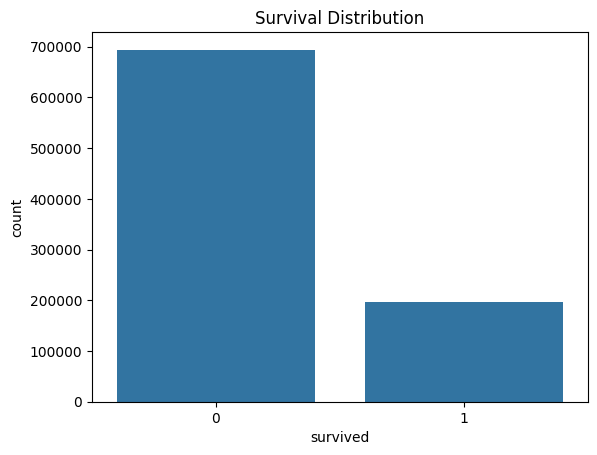

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='survived', data=lung_dataset)
plt.title("Survival Distribution")
plt.show()

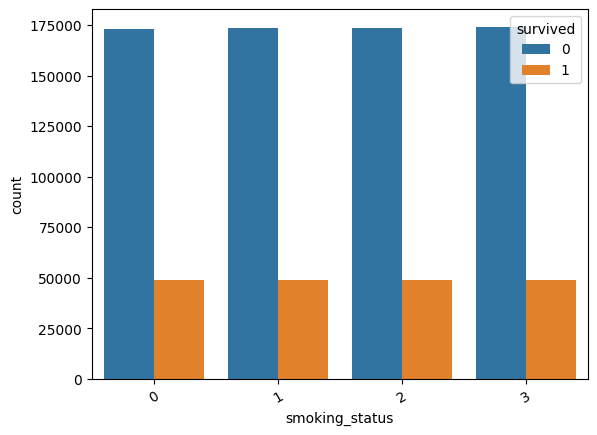

In [26]:
sns.countplot(
    x='smoking_status',
    hue='survived',
    data=lung_dataset
)

plt.xticks(rotation=30)
plt.show()

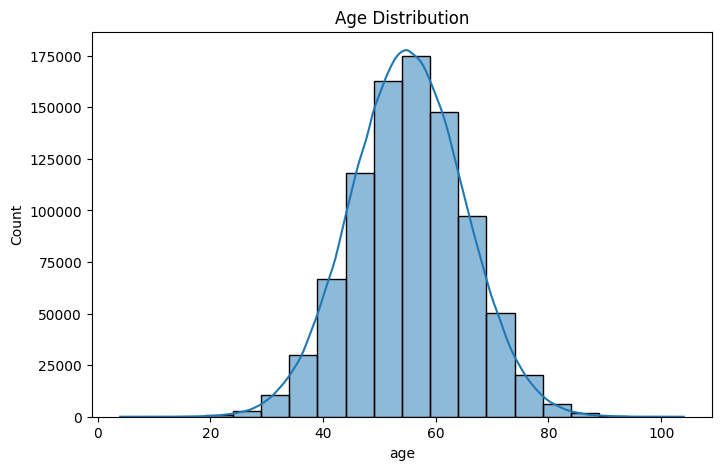

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(lung_dataset['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

In [28]:
x = lung_dataset.drop("survived", axis=1)
y = lung_dataset["survived"]

In [31]:
x.shape

(890000, 14)

In [32]:
smote = SMOTE(random_state=42)

x_resampled, y_resampled = smote.fit_resample(x, y)

In [33]:
x_train, x_test, y_train, y_test = train_test_split(
    x_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [34]:
print(x_train.shape)
print(x_test.shape)

(1110393, 14)
(277599, 14)


In [36]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
model.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [37]:
y_pred = model.predict(x_test)
y_pred

array([1, 0, 1, ..., 0, 1, 1])

In [38]:
x_train.head(1)

,age,gender,country,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,treatment_duration
227359,47.0,1,20,2,0,1,41.0,268,1,1,0,0,1,594


In [39]:
sample_patient = pd.DataFrame([{
    'age': 65,
    'gender': 1,
    'country': 5,
    'cancer_stage': 2,
    'family_history': 1,
    'smoking_status': 0,
    'bmi': 27.5,
    'cholesterol_level': 220,
    'hypertension': 1,
    'asthma': 0,
    'cirrhosis': 0,
    'other_cancer': 0,
    'treatment_type': 1,
    'treatment_duration': 180
}])

prediction = model.predict(sample_patient)

if prediction[0] == 1:
    print("Predicted Survival: Survived")
else:
    print("Predicted Survival: Not Survived")

Predicted Survival: Not Survived


In [41]:
print("nClassification Report:")
print(classification_report(y_test, y_pred))

nClassification Report:
              precision    recall  f1-score   support

           0       0.67      0.74      0.71    138614
           1       0.71      0.64      0.67    138985

    accuracy                           0.69    277599
   macro avg       0.69      0.69      0.69    277599
weighted avg       0.69      0.69      0.69    277599



In [50]:
import joblib

joblib.dump(label_encoders, "lung_cancer_encoders.pkl")

['lung_cancer_encoders.pkl']